# Customer Churn & Retention Analytics — Step 3: EDA

Goal here is to actually dig into the churn patterns instead of just eyeballing summary tables like in Step 1. Looking at this through the two business questions: **who is churning** and **why**. Using statistical tests alongside the charts so the findings aren't just "this bar looks bigger" — want to know if these differences are actually significant or could just be noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('telco_churn_cleaned.csv')
df.shape

(7043, 21)

## Churn overview

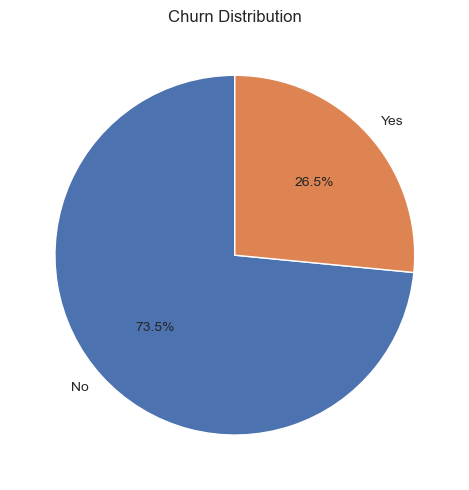

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [2]:
churn_counts = df['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(5,5))
colors = ['#4C72B0', '#DD8452']
ax.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Churn Distribution')
plt.tight_layout()
plt.show()

print(churn_counts)

26.5% churn rate confirmed again from Step 1. Moderate imbalance, not extreme, but I'll keep this in mind for the ML step later.

## Who is churning? — Categorical drivers

Looking at Contract, InternetService, and PaymentMethod first since these were the strongest categorical drivers found so far.

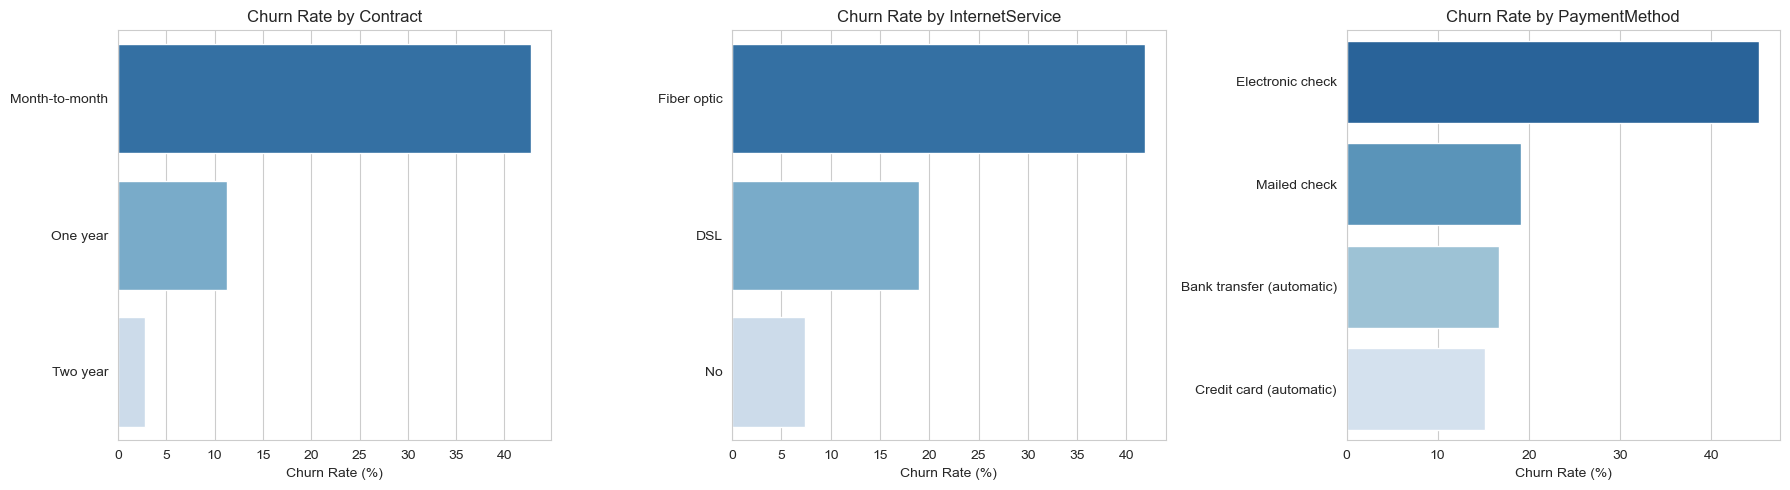

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index, hue=churn_rate.index, palette='Blues_r', legend=False, ax=ax)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Month-to-month contracts, fiber optic internet, and electronic check payment all stand out with noticeably higher churn. Fiber optic churning more than DSL is a bit surprising on the surface (usually a "better" service) — probably a price/expectations thing, worth checking against MonthlyCharges below.

### Statistical significance check — chi-square test

Checking whether these categorical relationships with Churn are actually statistically significant, not just visually different.

In [4]:
def cramers_v(confusion_matrix):
    # Cramer's V normalizes chi-square for sample size and table shape,
    # so it's a fairer way to compare "strength of association" across
    # columns than raw chi2 alone (which just gets bigger with more data
    # or more categories, regardless of how strong the relationship
    # actually is)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

results = []
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    results.append({
        'feature': col,
        'chi2': round(chi2, 2),
        'p_value': p,
        'cramers_v': round(cramers_v(contingency), 4),
        'significant': p < 0.05
    })

chi2_results = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
chi2_results

,feature,chi2,p_value,cramers_v,significant
13,Contract,1184.60,5.863038e-258,0.4101,True
7,OnlineSecurity,850.00,2.661150e-185,0.3474,True
10,TechSupport,828.20,1.443084e-180,0.3429,True
6,InternetService,732.31,9.571788e-160,0.3225,True
15,PaymentMethod,648.14,3.682355e-140,0.3034,True
8,OnlineBackup,601.81,2.079759e-131,0.2923,True
9,DeviceProtection,558.42,5.505219e-122,0.2816,True
12,StreamingMovies,375.66,2.667757e-82,0.2310,True
11,StreamingTV,374.20,5.528994e-82,0.2305,True
14,PaperlessBilling,258.28,4.073355e-58,0.1915,True


14 of the 16 categorical features come back statistically significant (p < 0.05) — `gender` and `PhoneService` are the two exceptions, with p-values well above 0.05, meaning there's no real evidence either one is associated with churn at all.

Ranking by raw `chi2` alone is a bit misleading though — chi2 grows with sample size and with how many categories a column has, so it's not a fair way to compare *strength* of association across different columns. Using **Cramér's V** instead (normalized to a 0-1 scale, comparable across columns) for the actual ranking below.

## Why are they leaving? — Numeric drivers

tenure, MonthlyCharges, TotalCharges split by churn status.

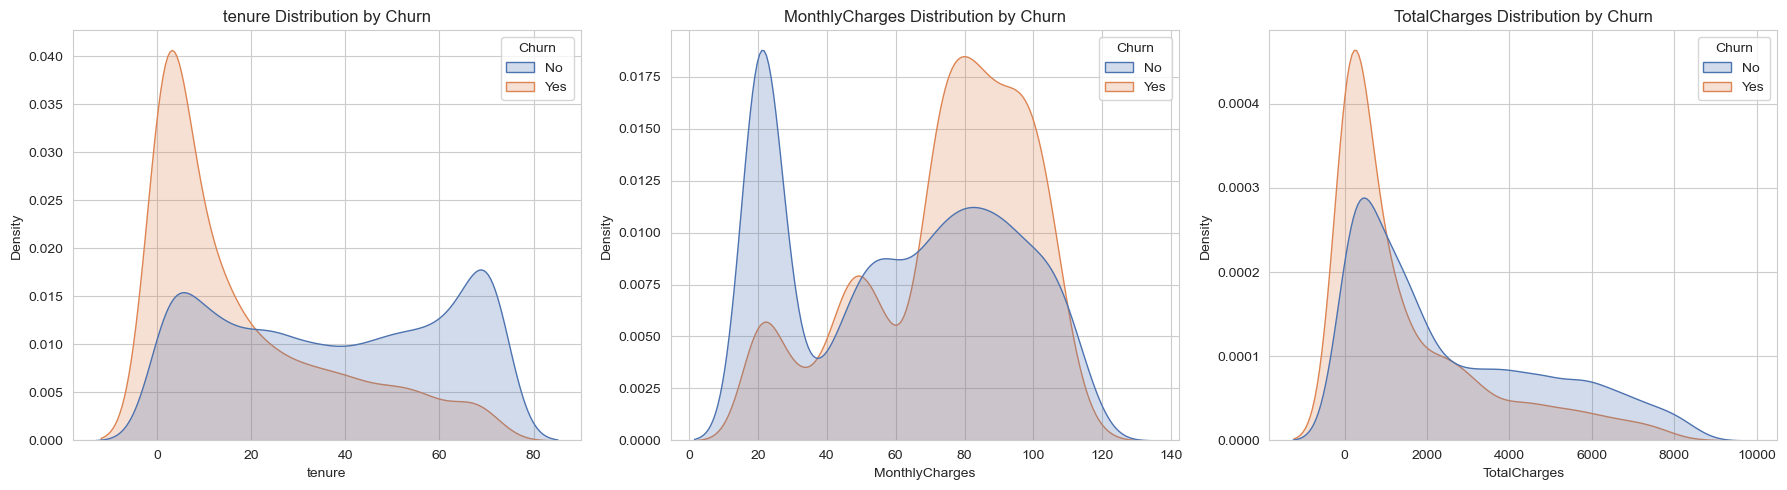

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=ax, palette=['#4C72B0','#DD8452'])
    ax.set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.show()

- `tenure`: churned customers are heavily skewed toward low tenure — big spike near 0, matches the "leaving early" pattern from the SQL analysis
- `MonthlyCharges`: churned customers cluster at the higher end (mostly $70-$100+), which explains the fiber optic pattern above — fiber optic is the pricier tier
- `TotalCharges`: churned customers skew low, but that's partly just a byproduct of low tenure (less time to accumulate charges), not necessarily its own independent signal

### Statistical significance check — t-test

Comparing churned vs. retained customers on each numeric column.

In [6]:
def cohens_d(group1, group2):
    # standardized effect size - tells us how big the gap actually is,
    # not just whether it's "statistically significant" (which p-value
    # alone can't do, especially with a sample this large)
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std()**2 + (n2 - 1) * group2.std()**2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    churned = df[df['Churn'] == 'Yes'][col]
    retained = df[df['Churn'] == 'No'][col]
    t_stat, p_val = stats.ttest_ind(churned, retained, equal_var=False)
    d = cohens_d(churned, retained)
    print(f"{col}: churned mean = {churned.mean():.2f}, retained mean = {retained.mean():.2f}, "
          f"p-value = {p_val:.2e}, Cohen's d = {d:.2f}")

tenure: churned mean = 17.98, retained mean = 37.57, p-value = 1.20e-232, Cohen's d = -0.85
MonthlyCharges: churned mean = 74.44, retained mean = 61.27, p-value = 8.59e-73, Cohen's d = 0.45
TotalCharges: churned mean = 1531.80, retained mean = 2549.91, p-value = 5.90e-75, Cohen's d = -0.46


All three numeric columns show a statistically significant difference between churned and retained customers, but the p-values alone don't tell us how *big* the gap is — with a sample this large, even small differences can hit p < 0.05. Cohen's d fills that gap:

- `tenure`: d ≈ -0.85 — a large effect by conventional thresholds (0.2 small, 0.5 medium, 0.8 large). This is the strongest numeric driver by a clear margin.
- `MonthlyCharges`: d ≈ 0.45 — a small-to-medium effect. Real, but nowhere near as decisive as tenure.
- `TotalCharges`: d ≈ -0.46 — similar, small-to-medium. Worth remembering this one is likely riding on the tenure effect rather than being independent (they're highly correlated, as the correlation check further down shows).

## Compounding risk: tenure x contract

Checking whether new customers on month-to-month contracts are an especially high-risk combination, since both factors independently point toward higher churn.

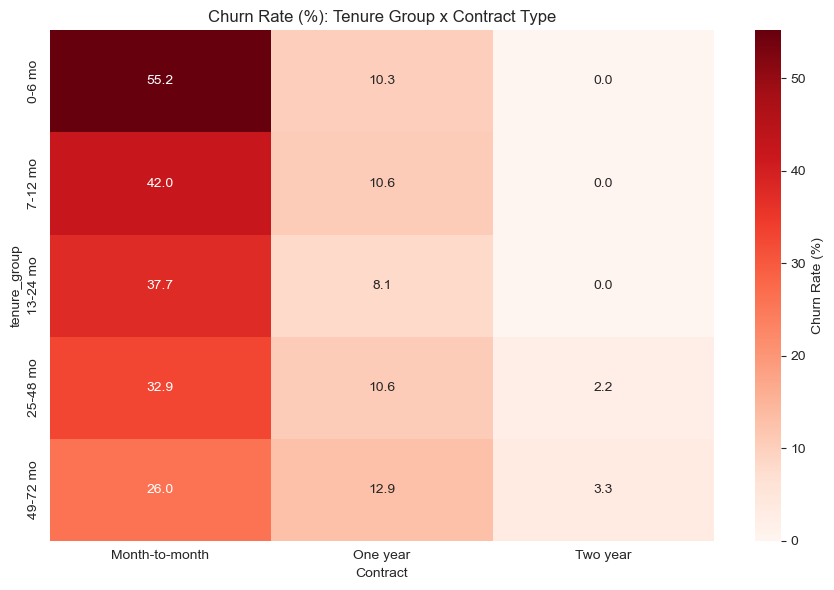

In [7]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 72],
                             labels=['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'])

pivot = df.groupby(['tenure_group', 'Contract'], observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Tenure Group x Contract Type')
plt.tight_layout()
plt.show()

This is the clearest picture yet — new (0-6 month) customers on month-to-month contracts churn at a much higher rate than any other combination, and it drops off fast as either tenure or contract length increases. This is the compounding risk pattern the retention strategy should target first.

## More interaction checks

Tenure x Contract was the strongest combined-risk pattern so far. Checking two more combinations that came up as top individual drivers on their own: pricing within contract type, and the two add-on services with the highest Cramér's V.

### MonthlyCharges x Contract

Are expensive month-to-month customers an especially high-risk group, or is contract type driving churn on its own regardless of price?

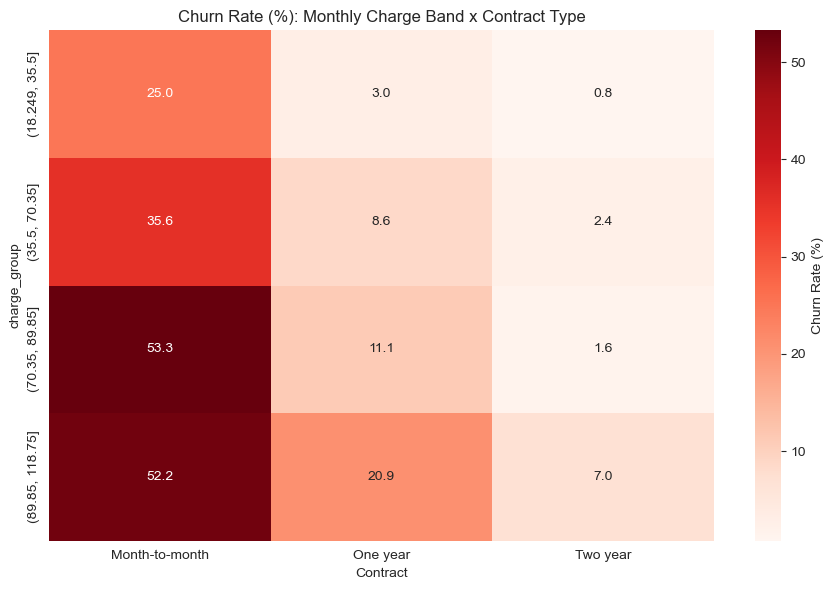

In [8]:
df['charge_group'] = pd.qcut(df['MonthlyCharges'], q=4, duplicates='drop')

pivot_charges = df.groupby(['charge_group', 'Contract'], observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot_charges, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Monthly Charge Band x Contract Type')
plt.tight_layout()
plt.show()

Both effects stack, but contract type dominates: even in the cheapest price band, month-to-month churns at 25.0% vs 3.0% (one year) and 0.8% (two year). Within month-to-month specifically, churn does climb with price — 25.0% → 35.6% → 53.3% → 52.2% across the four bands — so price sensitivity is real, but it's layered on top of the much bigger contract-type effect rather than replacing it. The highest-risk cell overall is month-to-month + $70.35-$89.85/month at 53.3%.

### TechSupport x OnlineSecurity

Both came up with high Cramér's V individually. Checking whether customers missing *both* are a distinctly higher-risk group than missing just one.

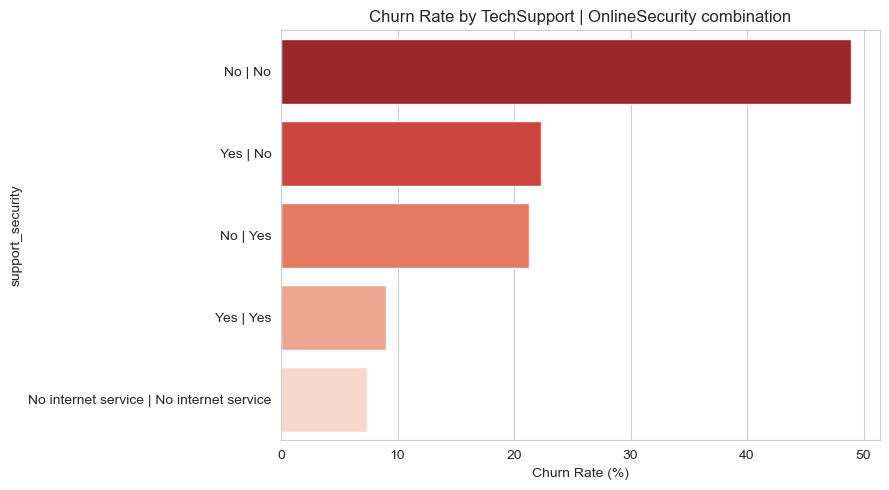

support_security
No | No                                      48.962005
Yes | No                                     22.328042
No | Yes                                     21.304348
Yes | Yes                                     9.008189
No internet service | No internet service     7.404980
Name: Churn, dtype: float64

In [9]:
df['support_security'] = df['TechSupport'].astype(str) + ' | ' + df['OnlineSecurity'].astype(str)

combo_churn = df.groupby('support_security')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=combo_churn.values, y=combo_churn.index, hue=combo_churn.index, palette='Reds_r', legend=False, ax=ax)
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by TechSupport | OnlineSecurity combination')
plt.tight_layout()
plt.show()

combo_churn

Confirmed — missing both is the clear worst case: **48.96%** churn for "No TechSupport | No OnlineSecurity", compared to ~21-22% for missing just one of the two, and 9.01% for customers with both. The "No internet service" combination sits lowest at 7.40% (these customers can't churn over an add-on they were never eligible for in the first place, so this group isn't really comparable to the others). This is a strong, actionable pair — customers with neither service are nearly 5x more likely to churn than customers with both.

## Correlation heatmap — numeric features

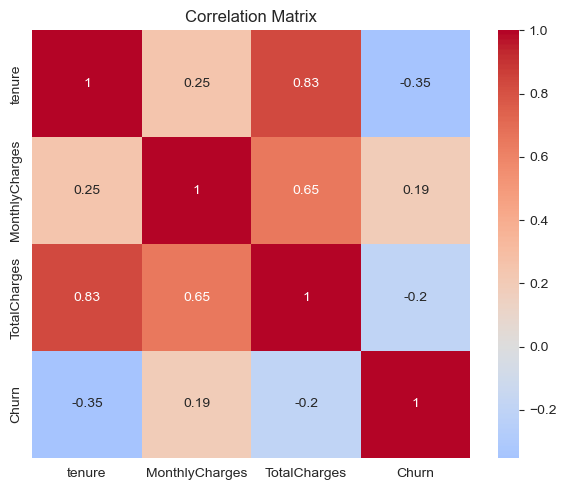

In [10]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

`tenure` has the strongest correlation with Churn (negative — longer tenure, less churn), which lines up with everything else so far. `TotalCharges` and `tenure` are highly correlated with each other (0.83), which makes sense (more months = more total spend) — worth remembering for the ML step, since including both as features could introduce multicollinearity.

## Summary

**Who is churning:**
- Month-to-month contract customers, fiber optic internet customers, and electronic check payers churn at the highest rates
- `gender` and `PhoneService` show no statistically significant relationship with churn at all — safe to exclude from anything downstream

**Why they're churning:**
- New customers (low tenure) churn far more than long-tenured ones — points to an onboarding/early-experience issue
- Higher `MonthlyCharges` correlates with higher churn, but this effect is smaller than contract type and mostly layers on top of it rather than replacing it
- The combination of new + month-to-month is the single highest-risk group in the data; missing both TechSupport and OnlineSecurity is nearly as strong a signal (48.96% churn vs 9.01% for customers with both)

**Statistical backing:**
- 14 of 16 categorical features are significantly associated with churn (chi-square); by Cramér's V, `Contract` (0.41), `OnlineSecurity` (0.35), and `TechSupport` (0.34) have the strongest actual associations — not just the largest chi2, which isn't a fair comparison across differently-sized columns
- All three numeric features differ significantly between churned/retained groups (t-test), but the practical size of that difference varies a lot: `tenure` has a large effect (Cohen's d ≈ -0.85), while `MonthlyCharges` and `TotalCharges` are only small-to-medium (d ≈ 0.45 and -0.46)
- `tenure` and `TotalCharges` are highly correlated with each other — flagging for the ML step

Next: use these confirmed drivers to build actual customer segments (Step 4).